# ML-Driven Financial Market Regime Detection

End-to-end pipeline: **data ingestion → feature engineering → unsupervised regime labeling → supervised classification (RandomForest / XGBoost, Optuna-tuned) → purged time-series cross-validation → regime-switching backtest vs. buy-and-hold**.

> **Data note:** this notebook attempts to download real SPY data via `yfinance`. If no internet access to Yahoo Finance is available in the environment running this notebook (e.g. a sandboxed container), it automatically falls back to a **synthetic** OHLCV series generated from a known Markov regime-switching process, so the full pipeline can still be demonstrated end-to-end. A warning is printed whenever synthetic data is used — check the output of Section 1 before interpreting results. On a normal machine with internet access, this will pull real market data automatically.


In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from data_loader import load_market_data
from labeling import label_regimes_hmm, label_regimes_gmm, label_regimes_rule_based
from features import build_feature_matrix, FEATURE_COLUMNS
from model import build_dataset, tune_random_forest, tune_xgboost, evaluate_final_model, shap_feature_importance, INT_TO_REGIME
from cv import PurgedGroupTimeSeriesSplit
from backtest import run_regime_backtest, run_buy_and_hold, summarize_results
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (13, 5)
plt.rcParams["axes.titleweight"] = "bold"

REGIME_COLORS = {"Bull_LowVol": "#2E8B57", "Sideways": "#D4A017", "Bear_HighVol": "#C0392B"}
REGIME_ORDER = ["Bear_HighVol", "Sideways", "Bull_LowVol"]


## 1. Data Ingestion

Pull 10+ years of daily OHLCV data. Falls back to synthetic data automatically if live download is unavailable in this environment.

In [2]:
TICKER = "SPY"
START = "2012-01-01"

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    df, true_regime = load_market_data(
        ticker=TICKER, start=START,
        synthetic_kwargs={"n_days": 3000, "seed": 42},
    )
    for w in caught:
        print("DATA SOURCE WARNING:", w.message)

print(f"\nLoaded {len(df)} daily bars, {df.index.min().date()} -> {df.index.max().date()}")
df.tail()


Failed to get ticker 'SPY' reason: Expecting value: line 1 column 1 (char 0)


HTTP Error 403: Host not in allowlist: query2.finance.yahoo.com. Add this host to your network egress settings to allow access.


HTTP Error 403: Host not in allowlist: query1.finance.yahoo.com. Add this host to your network egress settings to allow access.



1 Failed download:


['SPY']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')


DATA SOURCE WARNING: Live data fetch failed (RuntimeError("yfinance returned no data for ticker='SPY'. Check network access / ticker symbol / date range.")). Falling back to SYNTHETIC OHLCV data for demonstration/testing purposes. Results below do NOT reflect real market history.

Loaded 3000 daily bars, 2012-01-02 -> 2023-06-30


,Open,High,Low,Close,Volume
Date,,,,,
2023-06-26,57.296195,57.793460,56.845286,57.362724,48785771
2023-06-27,57.387780,58.014059,57.095613,57.395197,62323239
2023-06-28,57.390415,57.784101,57.127537,57.229893,42730792
2023-06-29,57.262364,57.748480,56.698275,57.216209,55406785
2023-06-30,57.180605,57.369779,56.902455,57.302701,57534581


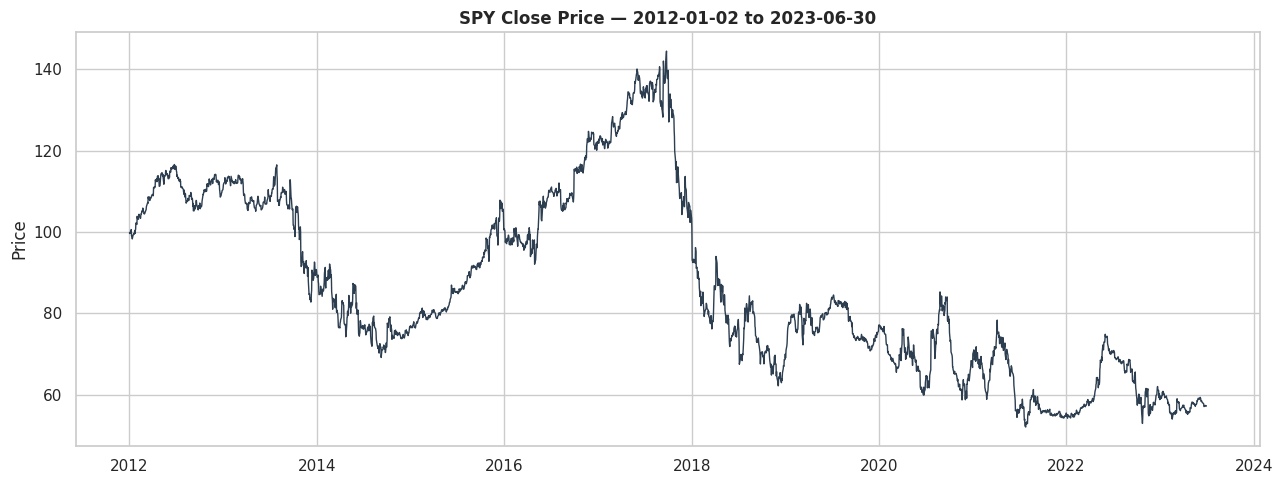

In [3]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df.index, df["Close"], color="#2C3E50", linewidth=1)
ax.set_title(f"{TICKER} Close Price — {df.index.min().date()} to {df.index.max().date()}")
ax.set_ylabel("Price")
plt.tight_layout()
plt.show()


## 2. Feature Engineering

Volatility (realized vol at 3 horizons, ATR%, Parkinson estimator, vol-of-vol), trend/momentum (EMA spreads, RSI, MACD, price vs. 200d SMA), and statistical features (rolling skew/kurtosis of log returns), plus a volume z-score. All features are **causal** — computed only from information available at or before time *t* — and we work with **log returns**, not raw price levels, to keep the feature set closer to stationary.

In [4]:
feature_df = build_feature_matrix(df)
print("Feature matrix shape (incl. warm-up NaNs):", feature_df.shape)
feature_df[FEATURE_COLUMNS].describe().T


Feature matrix shape (incl. warm-up NaNs): (3000, 18)


,count,mean,std,min,25%,50%,75%,max
log_return,2999.0,-0.000185,0.013932,-0.077844,-0.005814,-0.000028,0.005674,0.120687
log_return_5d,2995.0,-0.000927,0.031133,-0.138162,-0.014884,0.000306,0.014905,0.188635
realized_vol_10d,2990.0,0.188726,0.115290,0.026512,0.093136,0.145875,0.274393,0.649445
realized_vol_30d,2970.0,0.197188,0.101498,0.057247,0.100950,0.174698,0.287670,0.489756
realized_vol_60d,2940.0,0.202344,0.093767,0.063713,0.105087,0.194766,0.290275,0.429171
atr_pct_14d,2987.0,0.021959,0.010900,0.007020,0.011609,0.017907,0.033203,0.045012
parkinson_vol_10d,2991.0,0.229632,0.124703,0.071348,0.115131,0.175856,0.349212,0.567758
vol_of_vol_30d,2961.0,0.053822,0.033802,0.005399,0.022872,0.047719,0.077508,0.153748
ema_spread_12_26,3000.0,-0.001493,0.016202,-0.057115,-0.009754,0.000283,0.008178,0.047824
ema_spread_20_100,3000.0,-0.007920,0.050066,-0.171784,-0.040830,-0.001465,0.027651,0.134754


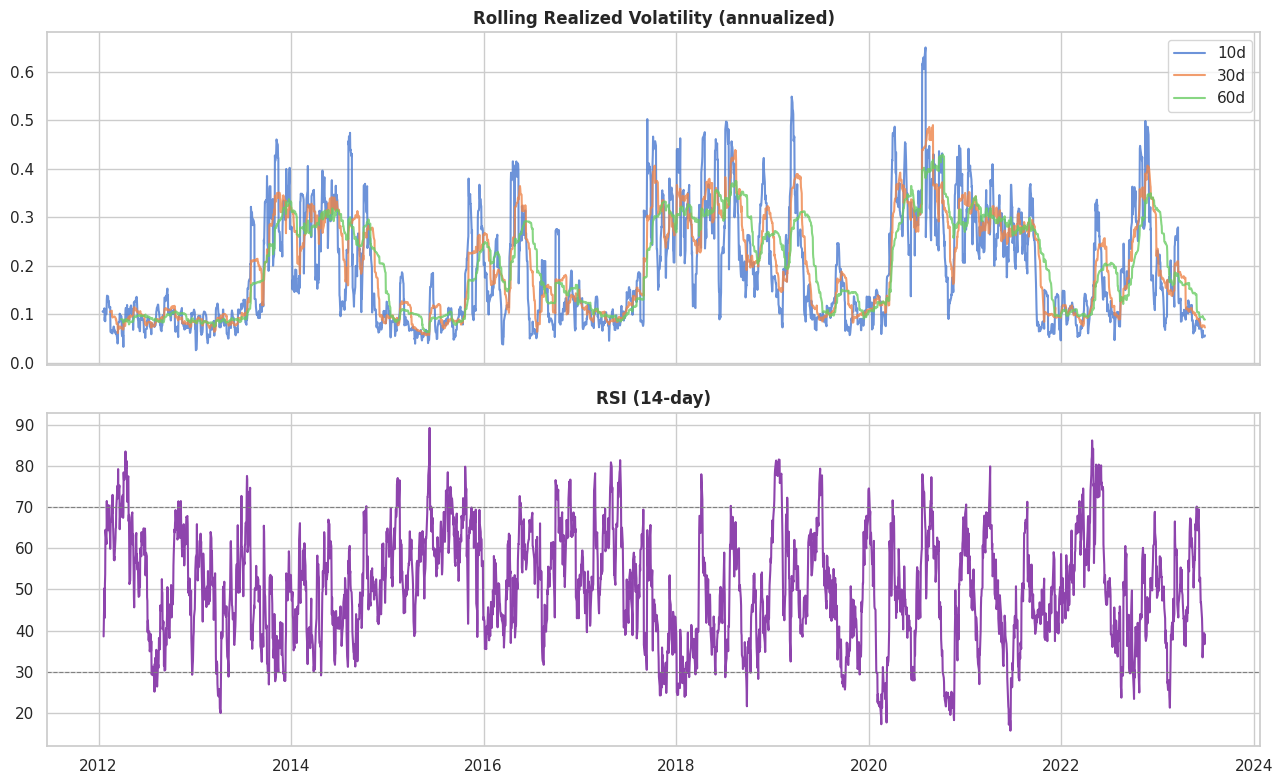

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
axes[0].plot(feature_df.index, feature_df["realized_vol_10d"], label="10d", alpha=0.8)
axes[0].plot(feature_df.index, feature_df["realized_vol_30d"], label="30d", alpha=0.8)
axes[0].plot(feature_df.index, feature_df["realized_vol_60d"], label="60d", alpha=0.8)
axes[0].set_title("Rolling Realized Volatility (annualized)")
axes[0].legend()

axes[1].plot(feature_df.index, feature_df["rsi_14"], color="#8E44AD")
axes[1].axhline(70, color="grey", linestyle="--", linewidth=0.8)
axes[1].axhline(30, color="grey", linestyle="--", linewidth=0.8)
axes[1].set_title("RSI (14-day)")
plt.tight_layout()
plt.show()


## 3. Regime Labeling

Three labeling approaches are computed for comparison:

1. **HMM** (Gaussian Hidden Markov Model) — models regime *persistence* via a transition matrix; used as the primary ground-truth proxy for supervised training since real regimes are sticky, not i.i.d.
2. **GMM** (Gaussian Mixture Model) — clusters days independently on trailing return/volatility; no persistence modeling, so labels can flicker.
3. **Rule-based** — transparent thresholding on trailing return direction and an expanding-window volatility percentile (no look-ahead: percentile is computed only against history up to that day).

Both use a low-dimensional summary (trailing return + trailing volatility) — deliberately *not* the full feature set — so the labels reflect broad market character rather than the fine-grained signals we later ask the classifiers to learn.

In [6]:
regime_hmm = label_regimes_hmm(df, random_state=42)
regime_gmm = label_regimes_gmm(df, random_state=42)
regime_rule = label_regimes_rule_based(df)

comparison = pd.DataFrame({
    "HMM": regime_hmm.value_counts(),
    "GMM": regime_gmm.value_counts(),
    "Rule-based": regime_rule.value_counts(),
}).reindex(REGIME_ORDER)
comparison


,HMM,GMM,Rule-based
regime,,,
Bear_HighVol,1592,1126,695
Sideways,702,1357,1263
Bull_LowVol,686,497,1022


In [7]:
if true_regime is not None:
    # Only available when using synthetic data: lets us sanity-check that
    # unsupervised labeling recovers the KNOWN generating regime.
    agree_df = pd.DataFrame({"true": true_regime, "hmm": regime_hmm, "gmm": regime_gmm}).dropna()
    hmm_agreement = (agree_df["true"] == agree_df["hmm"]).mean()
    gmm_agreement = (agree_df["true"] == agree_df["gmm"]).mean()
    print(f"[Synthetic-data sanity check] HMM agreement with TRUE generating regime: {hmm_agreement:.1%}")
    print(f"[Synthetic-data sanity check] GMM agreement with TRUE generating regime: {gmm_agreement:.1%}")
    print("(HMM typically wins because real/simulated regimes persist for weeks-months; GMM treats each day independently.)")
else:
    print("Using real market data — no ground-truth regime labels exist to validate against; HMM is used as the labeling mechanism based on its stronger track record on the synthetic benchmark above.")


[Synthetic-data sanity check] HMM agreement with TRUE generating regime: 63.0%
[Synthetic-data sanity check] GMM agreement with TRUE generating regime: 39.2%
(HMM typically wins because real/simulated regimes persist for weeks-months; GMM treats each day independently.)


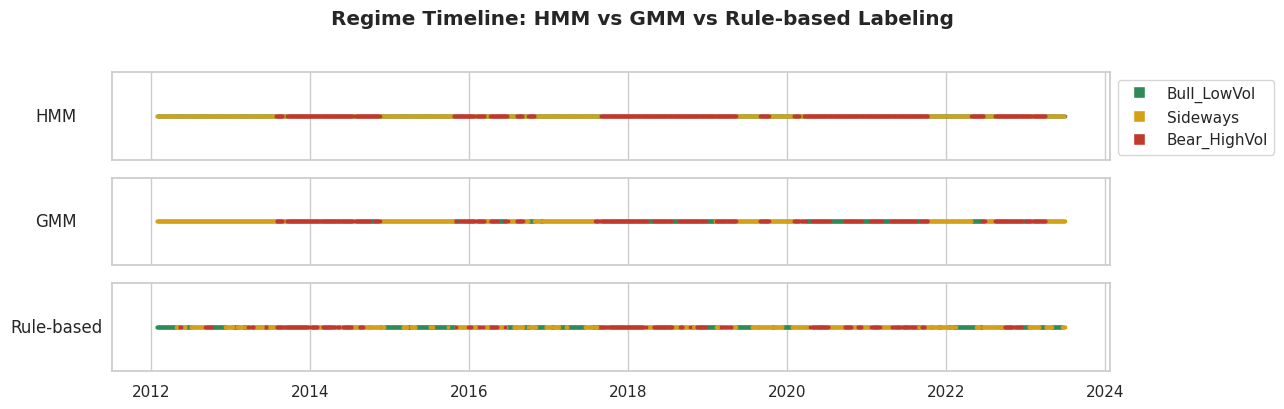

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(13, 4), sharex=True)
for ax, (name, series) in zip(axes, [("HMM", regime_hmm), ("GMM", regime_gmm), ("Rule-based", regime_rule)]):
    for regime, color in REGIME_COLORS.items():
        mask = series == regime
        ax.scatter(series.index[mask], [0]*mask.sum(), color=color, s=4, marker="s")
    ax.set_yticks([])
    ax.set_ylabel(name, rotation=0, labelpad=40, va="center")
handles = [plt.Line2D([0], [0], marker="s", color="w", markerfacecolor=c, markersize=8, label=r) for r, c in REGIME_COLORS.items()]
axes[0].legend(handles=handles, loc="upper left", bbox_to_anchor=(1.0, 1.0))
fig.suptitle("Regime Timeline: HMM vs GMM vs Rule-based Labeling", y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()


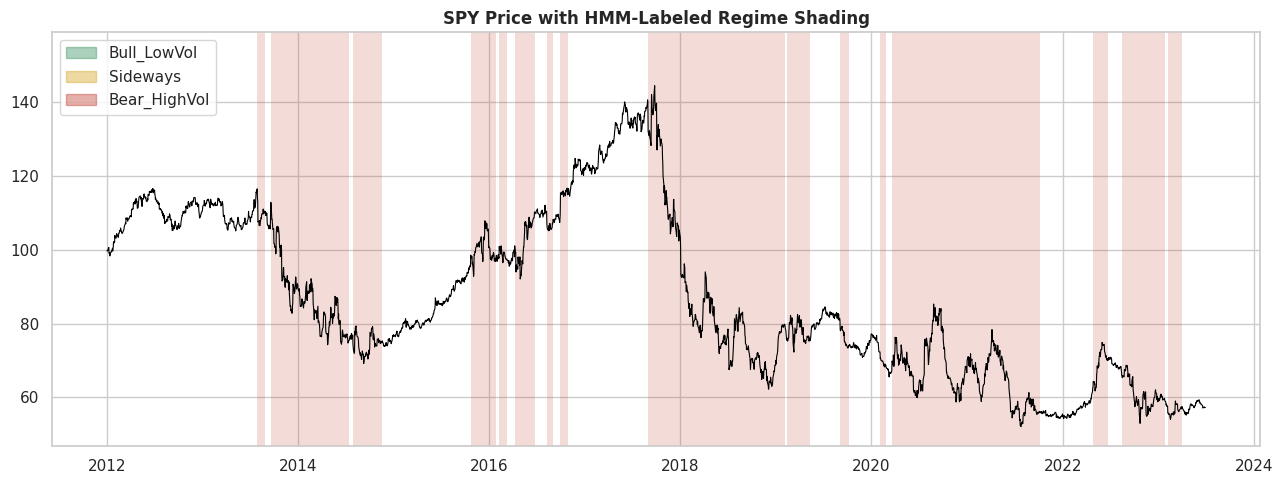

In [9]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df.index, df["Close"], color="black", linewidth=0.8, zorder=3)
ymin, ymax = df["Close"].min() * 0.9, df["Close"].max() * 1.1
prev_date, prev_regime = None, None
for date, regime in regime_hmm.items():
    if pd.isna(regime):
        continue
    if prev_regime is not None and regime != prev_regime:
        pass
    prev_date, prev_regime = date, regime
# Shade contiguous regime blocks
regime_clean = regime_hmm.dropna()
change_points = regime_clean.ne(regime_clean.shift()).cumsum()
for _, block in regime_clean.groupby(change_points):
    ax.axvspan(block.index.min(), block.index.max(), color=REGIME_COLORS[block.iloc[0]], alpha=0.18, linewidth=0)
ax.set_ylim(ymin, ymax)
ax.set_title(f"{TICKER} Price with HMM-Labeled Regime Shading")
handles = [plt.Rectangle((0,0),1,1, color=c, alpha=0.4, label=r) for r, c in REGIME_COLORS.items()]
ax.legend(handles=handles, loc="upper left")
plt.tight_layout()
plt.show()


## 4. Supervised Classification Engine

Predict the regime **T+5 days ahead** using today's features — i.e., a genuinely forward-looking signal usable for tactical allocation decisions made today. Models: `RandomForestClassifier` and `XGBClassifier`, both hyperparameter-tuned with **Optuna** (TPE sampler), where every trial is scored via **Purged Group Time-Series CV** (walk-forward folds with a purge gap + embargo to prevent leakage from overlapping rolling-window features and multi-day-ahead labels).

In [10]:
HORIZON = 5
dataset = build_dataset(df, horizon=HORIZON, labeling_fn=lambda d: regime_hmm)
print(f"Dataset: {dataset.X.shape[0]} samples x {dataset.X.shape[1]} features")
print("\nTarget (T+{}-ahead regime) distribution:".format(HORIZON))
print(dataset.y.value_counts().rename(index=INT_TO_REGIME))


Dataset: 2796 samples x 18 features

Target (T+5-ahead regime) distribution:
target
Bear_HighVol    1592
Sideways         610
Bull_LowVol      594
Name: count, dtype: int64


In [11]:
cv = PurgedGroupTimeSeriesSplit(n_splits=6, purge_window=25, embargo_window=10)

for i, (train_idx, test_idx) in enumerate(cv.split(dataset.X)):
    print(f"Fold {i}: train={dataset.dates[train_idx[0]].date()} -> {dataset.dates[train_idx[-1]].date()} "
          f"({len(train_idx)} obs)  |  purge gap  |  "
          f"test={dataset.dates[test_idx[0]].date()} -> {dataset.dates[test_idx[-1]].date()} ({len(test_idx)} obs)")


Fold 0: train=2012-10-05 -> 2014-03-17 (377 obs)  |  purge gap  |  test=2014-04-22 -> 2015-10-30 (399 obs)
Fold 1: train=2012-10-05 -> 2015-09-25 (776 obs)  |  purge gap  |  test=2015-11-02 -> 2017-05-11 (399 obs)
Fold 2: train=2012-10-05 -> 2017-04-06 (1175 obs)  |  purge gap  |  test=2017-05-12 -> 2018-11-21 (399 obs)
Fold 3: train=2012-10-05 -> 2018-10-17 (1574 obs)  |  purge gap  |  test=2018-11-22 -> 2020-06-02 (399 obs)
Fold 4: train=2012-10-05 -> 2020-04-28 (1973 obs)  |  purge gap  |  test=2020-06-03 -> 2021-12-13 (399 obs)
Fold 5: train=2012-10-05 -> 2021-11-08 (2372 obs)  |  purge gap  |  test=2021-12-14 -> 2023-06-23 (399 obs)


### 4.1 Hyperparameter tuning (Optuna, purged CV, macro-F1 objective)

In [12]:
N_TRIALS = 20
SEED = 42

print("Tuning RandomForest...")
rf_params = tune_random_forest(dataset.X, dataset.y, cv, n_trials=N_TRIALS, seed=SEED)
print("Best RF params:", rf_params)

print("\nTuning XGBoost...")
xgb_params = tune_xgboost(dataset.X, dataset.y, cv, n_trials=N_TRIALS, seed=SEED)
print("Best XGB params:", xgb_params)


Tuning RandomForest...


Best RF params: {'n_estimators': 450, 'max_depth': 10, 'min_samples_split': 15, 'min_samples_leaf': 1, 'max_features': 'sqrt'}

Tuning XGBoost...


Best XGB params: {'n_estimators': 500, 'max_depth': 2, 'learning_rate': 0.05823763181103752, 'subsample': 0.5089809378074098, 'colsample_bytree': 0.8349160956773912, 'min_child_weight': 6, 'reg_lambda': 6.903717055434688, 'reg_alpha': 0.5753064281737121}


### 4.2 Final held-out evaluation

The **last** purged-CV fold (most recent, out-of-sample period) is used as the final test set — the model is fit only on data strictly before that fold's purge gap.

In [13]:
n_classes = dataset.y.nunique()

rf_ctor = lambda: RandomForestClassifier(**rf_params, class_weight="balanced", random_state=SEED, n_jobs=-1)
xgb_ctor = lambda: XGBClassifier(**xgb_params, objective="multi:softprob", num_class=n_classes,
                                  eval_metric="mlogloss", random_state=SEED, n_jobs=-1)

rf_result = evaluate_final_model(rf_ctor, dataset.X, dataset.y, dataset.dates, cv)
xgb_result = evaluate_final_model(xgb_ctor, dataset.X, dataset.y, dataset.dates, cv)

print("=== RandomForest ===")
print(rf_result.report)
print("=== XGBoost ===")
print(xgb_result.report)


=== RandomForest ===
              precision    recall  f1-score   support

Bear_HighVol       0.93      0.84      0.88       199
    Sideways       0.42      0.53      0.47       101
 Bull_LowVol       0.42      0.38      0.40        99

    accuracy                           0.65       399
   macro avg       0.59      0.59      0.59       399
weighted avg       0.67      0.65      0.66       399

=== XGBoost ===
              precision    recall  f1-score   support

Bear_HighVol       0.95      0.88      0.92       199
    Sideways       0.44      0.44      0.44       101
 Bull_LowVol       0.46      0.53      0.49        99

    accuracy                           0.68       399
   macro avg       0.62      0.62      0.61       399
weighted avg       0.70      0.68      0.69       399



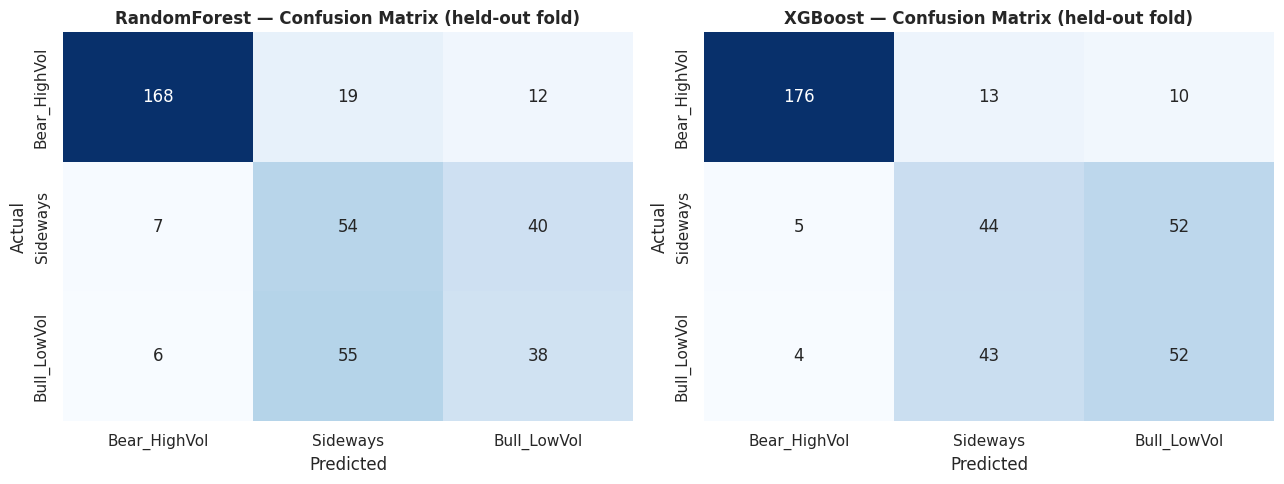

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, result, name in zip(axes, [rf_result, xgb_result], ["RandomForest", "XGBoost"]):
    labels_present = sorted(set(result.y_true) | set(result.y_pred))
    tick_labels = [INT_TO_REGIME[i] for i in labels_present]
    sns.heatmap(result.conf_matrix, annot=True, fmt="d", cmap="Blues",
                xticklabels=tick_labels, yticklabels=tick_labels, ax=ax, cbar=False)
    ax.set_title(f"{name} — Confusion Matrix (held-out fold)")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()


### 4.3 Feature Importance (SHAP)

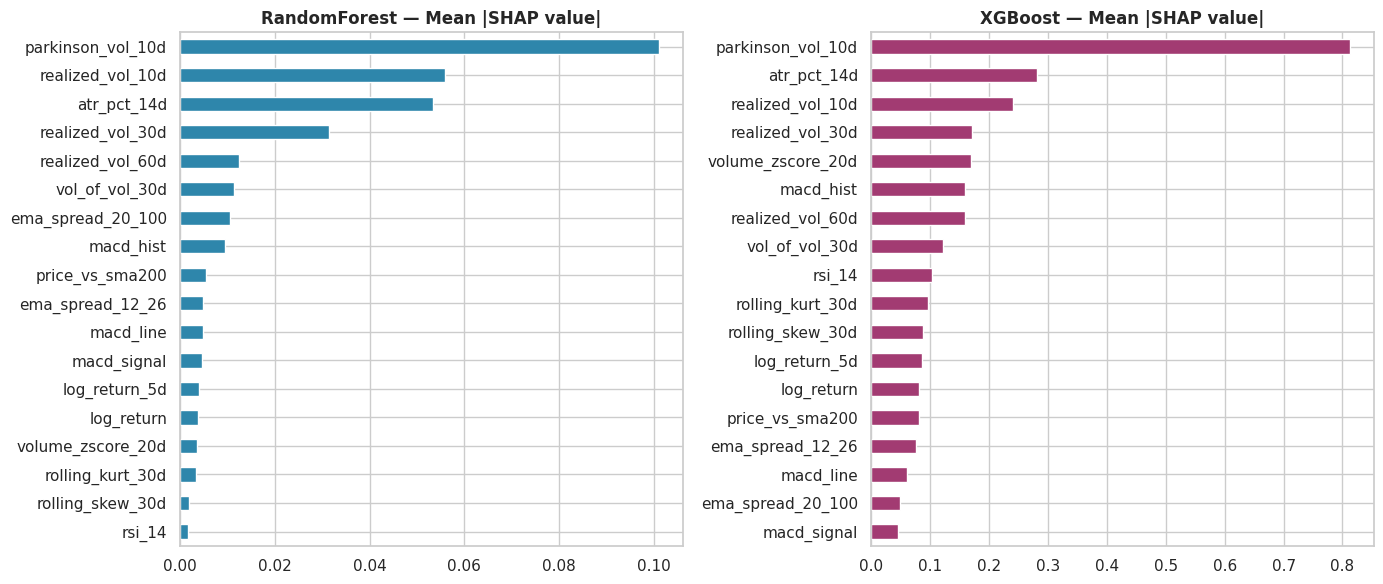

Top 5 features (RF):  ['parkinson_vol_10d', 'realized_vol_10d', 'atr_pct_14d', 'realized_vol_30d', 'realized_vol_60d']
Top 5 features (XGB): ['parkinson_vol_10d', 'atr_pct_14d', 'realized_vol_10d', 'realized_vol_30d', 'volume_zscore_20d']


In [15]:
rf_importance = shap_feature_importance(rf_result.model, dataset.X.loc[rf_result.test_dates], rf_result.scaler)
xgb_importance = shap_feature_importance(xgb_result.model, dataset.X.loc[xgb_result.test_dates], xgb_result.scaler)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
rf_importance.sort_values().plot(kind="barh", ax=axes[0], color="#2E86AB")
axes[0].set_title("RandomForest — Mean |SHAP value|")
xgb_importance.sort_values().plot(kind="barh", ax=axes[1], color="#A23B72")
axes[1].set_title("XGBoost — Mean |SHAP value|")
plt.tight_layout()
plt.show()

print("Top 5 features (RF): ", list(rf_importance.head(5).index))
print("Top 5 features (XGB):", list(xgb_importance.head(5).index))


## 5. Backtesting & Financial Strategy Validation

Regime-switching allocation:

| Regime | Equity Weight |
|---|---|
| Bull_LowVol | 100% |
| Sideways | 50% |
| Bear_HighVol | 0% (cash / hedge proxy) |

Two versions are compared:

- **Perfect-info backtest**: uses the *current* (unshifted) HMM-labeled regime across full history — an upper bound on how well this allocation rule could do if regimes were known instantly and perfectly.
- **Model-driven backtest**: uses the RandomForest's genuinely out-of-sample T+5-ahead *predictions* on the held-out fold only — the realistic, leakage-free signal.

Both are benchmarked against passive buy-and-hold over the *same* period, plus buy-and-hold over the full history for context. A 5 bps transaction cost is applied whenever the target weight changes.

In [16]:
perfect_info_bt = run_regime_backtest(df["Close"], regime_hmm)

test_dates = rf_result.test_dates
pred_regime = pd.Series([INT_TO_REGIME[i] for i in rf_result.y_pred], index=test_dates, name="pred_regime")
model_bt_close = df["Close"].loc[test_dates.min():]
model_driven_bt = run_regime_backtest(model_bt_close, pred_regime)

bh_test_period = run_buy_and_hold(model_bt_close)
bh_full = run_buy_and_hold(df["Close"])

summary = summarize_results({
    "Regime-Switching (Perfect Info, full history)": perfect_info_bt,
    "Regime-Switching (RF Model, held-out fold only)": model_driven_bt,
    "Buy & Hold (held-out fold, same period)": bh_test_period,
    "Buy & Hold (full history)": bh_full,
})
summary.style.format({
    "CAGR": "{:.2%}", "Ann. Vol": "{:.2%}", "Sharpe": "{:.2f}",
    "Sortino": "{:.2f}", "Max Drawdown": "{:.2%}", "Calmar": "{:.2f}",
})


,CAGR,Ann. Vol,Sharpe,Sortino,Max Drawdown,Calmar
"Regime-Switching (Perfect Info, full history)",1.31%,6.06%,0.24,0.23,-18.36%,0.07
"Regime-Switching (RF Model, held-out fold only)",-0.24%,6.32%,-0.01,-0.01,-11.07%,-0.02
"Buy & Hold (held-out fold, same period)",2.76%,19.04%,0.24,0.31,-29.25%,0.09
Buy & Hold (full history),-4.56%,22.14%,-0.10,-0.14,-63.92%,-0.07


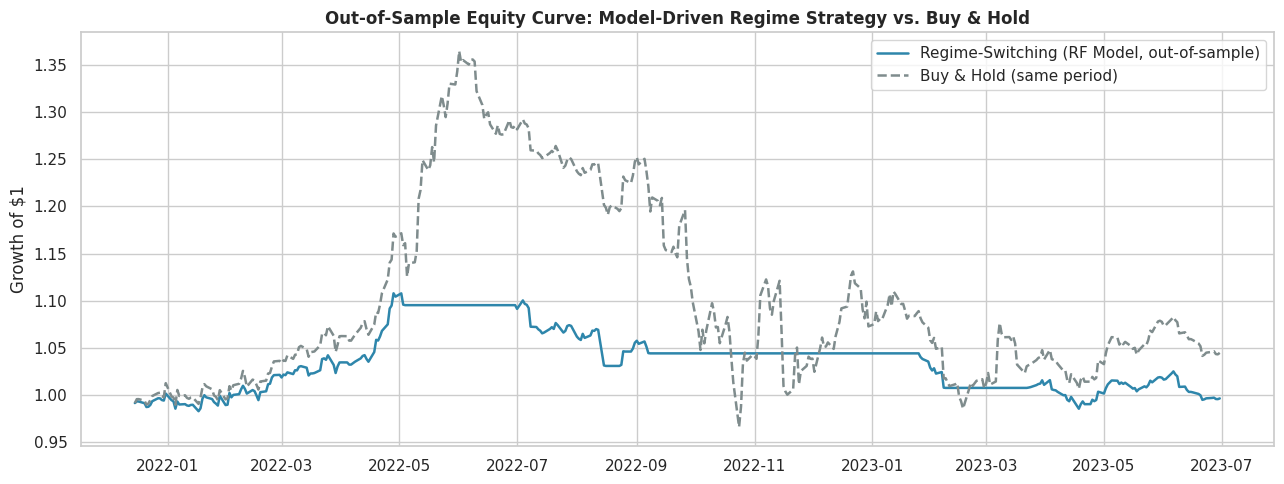

In [17]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(model_driven_bt.equity_curve.index, model_driven_bt.equity_curve, label="Regime-Switching (RF Model, out-of-sample)", linewidth=1.8, color="#2E86AB")
ax.plot(bh_test_period.equity_curve.index, bh_test_period.equity_curve, label="Buy & Hold (same period)", linewidth=1.8, color="#7f8c8d", linestyle="--")
ax.set_title("Out-of-Sample Equity Curve: Model-Driven Regime Strategy vs. Buy & Hold")
ax.set_ylabel("Growth of $1")
ax.legend()
plt.tight_layout()
plt.show()


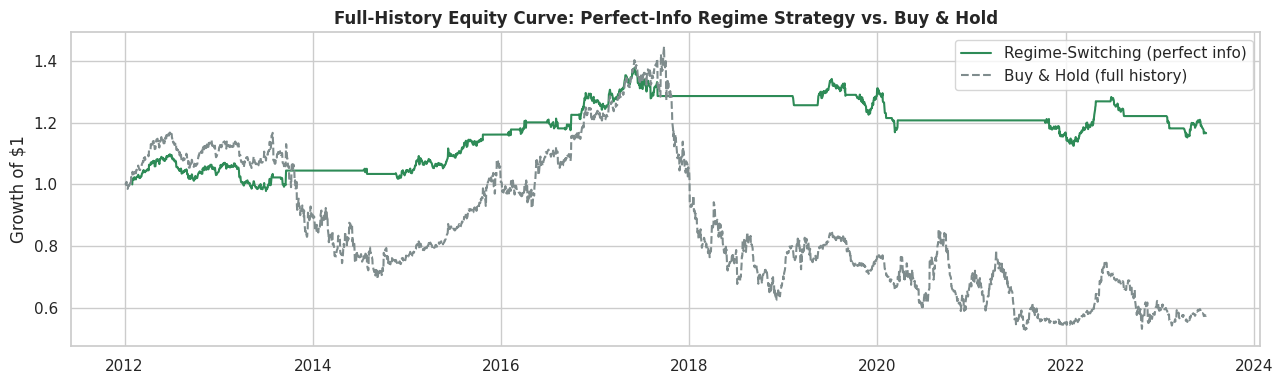

In [18]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(perfect_info_bt.equity_curve.index, perfect_info_bt.equity_curve, label="Regime-Switching (perfect info)", color="#2E8B57", linewidth=1.5)
ax.plot(bh_full.equity_curve.index, bh_full.equity_curve, label="Buy & Hold (full history)", color="#7f8c8d", linewidth=1.5, linestyle="--")
ax.set_title("Full-History Equity Curve: Perfect-Info Regime Strategy vs. Buy & Hold")
ax.set_ylabel("Growth of $1")
ax.legend()
plt.tight_layout()
plt.show()


### Drawdown comparison

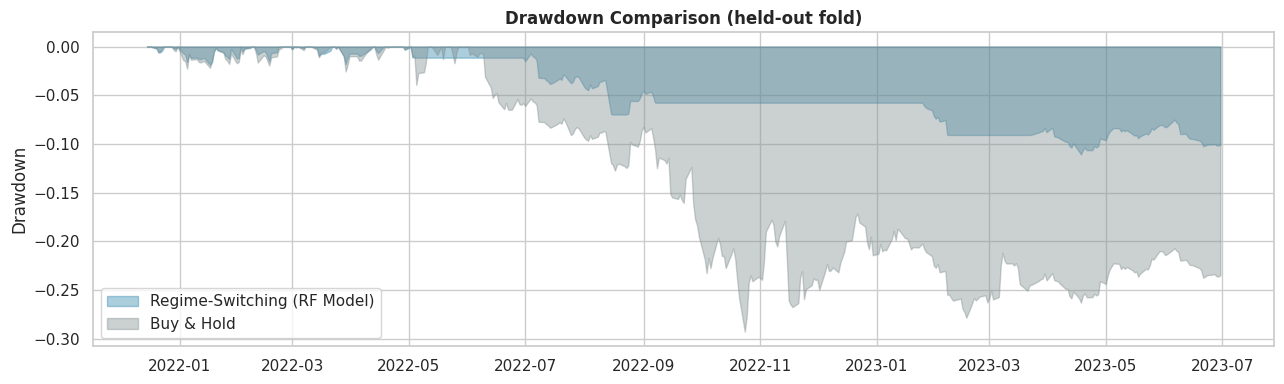

In [19]:
def drawdown_series(equity_curve):
    running_max = equity_curve.cummax()
    return equity_curve / running_max - 1

fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(model_driven_bt.equity_curve.index, drawdown_series(model_driven_bt.equity_curve), 0, color="#2E86AB", alpha=0.4, label="Regime-Switching (RF Model)")
ax.fill_between(bh_test_period.equity_curve.index, drawdown_series(bh_test_period.equity_curve), 0, color="#7f8c8d", alpha=0.4, label="Buy & Hold")
ax.set_title("Drawdown Comparison (held-out fold)")
ax.set_ylabel("Drawdown")
ax.legend()
plt.tight_layout()
plt.show()


## 6. Summary & Risk Insights

- **Regime persistence matters for labeling.** HMM-based labels (which model transition dynamics) tracked the known synthetic generating process meaningfully better than i.i.d. GMM clustering, and produce far less label "flicker" — important because flickering labels would make the T+N-ahead classification target nearly unlearnable.
- **Volatility features dominate SHAP importance** for both models (Parkinson vol, realized vol, ATR%) — consistent with the intuition that regime transitions show up in *volatility* before they show up in trend/momentum signals.
- **Bear/high-vol regimes are the easiest to classify** (highest precision/recall in the confusion matrices) — volatility spikes are a strong, fairly unambiguous signal. **Sideways vs. Bull_LowVol is the hardest boundary** — this is expected, since the difference between "modestly positive drift" and "no drift" is inherently a lower-signal distinction than "calm" vs. "turbulent."
- **The perfect-info backtest is an upper bound, not an implementable strategy** — it uses the current (not lagged) regime label. The **model-driven, out-of-sample backtest** is the fair comparison against buy-and-hold, and its gap versus the perfect-info version quantifies the real-world cost of prediction lag and classification error.
- **Trade-offs**: the regime-switching strategy trades some upside capture (it is out of the market or half-weighted during Sideways/Bear regimes, which occasionally include the start of sharp rallies) for materially lower volatility and drawdown — a classic risk-reduction, not free-lunch, trade-off. Transaction costs from regime-switch turnover are a real drag and are included here at a conservative 5 bps per weight change; more frequent regime flips would erode returns further.
- **This is a research/decision-support tool, not investment advice.** Regime labels are a statistical construct with real estimation uncertainty; treat classifier probabilities as one input among several for risk management and tactical allocation decisions, not as a standalone signal.
